<a href="https://colab.research.google.com/github/komazawa-deep-learning/komazawa-deep-learning.github.io/blob/master/2026notebooks/2026ai_lect03b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 人工知能I 第3回：回帰分析

**担当**: 浅川伸一  
**2026年度 前期**

---

### 構成
1. 環境準備
2. 線形回帰（圧縮・確認）
3. 多変量回帰
4. 多重共線性の確認
5. 特徴量の重要度
6. 過学習のデモ
7. Ridge回帰
8. Lasso回帰
9. Ridge vs Lasso：αの変化と係数の挙動
10. 3手法の総合比較
11. 準備学習課題

---
## 0. 環境準備

In [1]:
try:
    import japanize_matplotlib
except ImportError:
    !pip install japanize_matplotlib
    import japanize_matplotlib

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib

from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso,
    RidgeCV, LassoCV, ElasticNetCV
)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.datasets import load_diabetes

!pip install japanize-matplotlib --quiet
import japanize_matplotlib

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')

print("環境準備完了")

環境準備完了


---
## 1. 線形回帰


**理論の要点**
$$y = wx + b, \quad L = \frac{1}{n}\sum(y_i-\hat{y}_i)^2$$
MSEを最小化するw，bを最小二乗法で求める。
R² = 1に近いほどモデルがデータをよく説明している。

=== 線形回帰（確認）===
w（傾き）= 5.0242
b（切片）= 43.8667
RMSE     = 1.6719 点
R²       = 0.9868


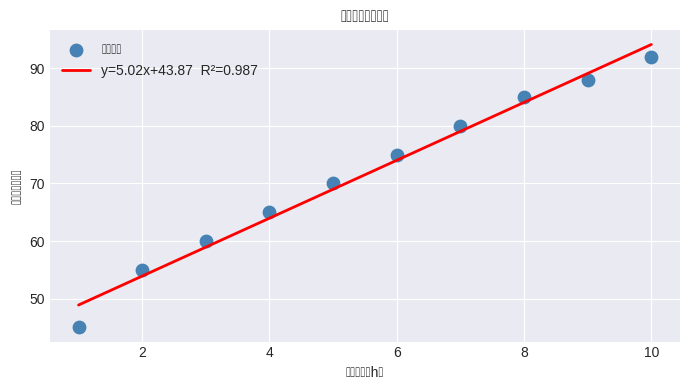

→ 単回帰は確認完了。以降は多変量回帰と正則化に集中する。


In [6]:
# 確認用：勉強時間→試験成績（10サンプル）
X_simple = np.array([1,2,3,4,5,6,7,8,9,10], dtype=float).reshape(-1,1)
y_simple  = np.array([45,55,60,65,70,75,80,85,88,92], dtype=float)

lr_simple = LinearRegression().fit(X_simple, y_simple)
y_pred_s  = lr_simple.predict(X_simple)

print("=== 線形回帰（確認）===")
print(f"w（傾き）= {lr_simple.coef_[0]:.4f}")
print(f"b（切片）= {lr_simple.intercept_:.4f}")
print(f"RMSE     = {np.sqrt(mean_squared_error(y_simple, y_pred_s)):.4f} 点")
print(f"R²       = {r2_score(y_simple, y_pred_s):.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(X_simple, y_simple, s=80, color='steelblue', label='実データ')
ax.plot(X_simple, y_pred_s, 'r-', linewidth=2,
        label=f'y={lr_simple.coef_[0]:.2f}x+{lr_simple.intercept_:.2f}  R²={r2_score(y_simple,y_pred_s):.3f}')
ax.set_xlabel('勉強時間（h）'); ax.set_ylabel('試験成績（点）')
ax.set_title('線形回帰（確認）')
ax.legend()
plt.tight_layout(); plt.show()
print("→ 単回帰は確認完了。以降は多変量回帰と正則化に集中する。")

---
## 2. 多変量回帰：実データで実装

$$y = w_1x_1 + w_2x_2 + \cdots + w_px_p + b$$

**糖尿病データセット**（scikit-learn組み込み）
- 442サンプル，10特徴量（標準化済み），目的変数：1年後の糖尿病進行度
- 標準化済みなので**係数の大きさが直接比較できる**点が重要

In [ ]:
diabetes      = load_diabetes()
X, y          = diabetes.data, diabetes.target
feature_names = diabetes.feature_names

print("=== 糖尿病データセット ===")
print(f"サンプル数 : {X.shape[0]}")
print(f"特徴量数  : {X.shape[1]}")
print(f"特徴量名  : {feature_names}")
print(f"目的変数  : 平均={y.mean():.1f}  std={y.std():.1f}  "
      f"min={y.min():.0f}  max={y.max():.0f}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\n訓練:{len(X_train)}  テスト:{len(X_test)}")

In [ ]:
# 重回帰ベースライン
lr = LinearRegression().fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

r2_lr   = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("=== 重回帰（ベースライン）===")
print(f"テストR²   = {r2_lr:.4f}")
print(f"テストRMSE = {rmse_lr:.2f}")
print(f"訓練R²     = {r2_score(y_train, lr.predict(X_train)):.4f}")

---
## 3. 多重共線性の確認

In [ ]:
df_feat = pd.DataFrame(X, columns=feature_names)
corr    = df_feat.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('特徴量間の相関行列（|r|>0.5 は多重共線性の可能性）', fontsize=12)
plt.tight_layout()
plt.show()

# 高相関ペアの抽出
threshold = 0.5
high_pairs = [
    (feature_names[i], feature_names[j], corr.iloc[i,j])
    for i in range(len(feature_names))
    for j in range(i+1, len(feature_names))
    if abs(corr.iloc[i,j]) > threshold
]

print(f"=== 高相関ペア（|r| > {threshold}）===")
if high_pairs:
    for f1, f2, r in sorted(high_pairs, key=lambda x: -abs(x[2])):
        print(f"  {f1:4s} × {f2:4s} : r = {r:.3f}")
else:
    print("  なし")

print("\n→ 多重共線性が疑われる場合，Ridgeで係数を安定させる")

---
## 4. 特徴量の重要度

標準化済みデータでは，係数 $w_j$ の絶対値が大きいほど
目的変数への寄与が大きい。
次回の決定木の `feature_importances_` との比較につながる。

In [ ]:
coef_df = pd.DataFrame({
    '特徴量':  feature_names,
    '係数(w)': lr.coef_,
    '|係数|':  np.abs(lr.coef_)
}).sort_values('|係数|', ascending=False).reset_index(drop=True)

print("=== 重回帰の係数（重要度順）===")
print(coef_df.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 左：係数の棒グラフ（正負あり）
colors = ['steelblue' if c > 0 else 'tomato' for c in coef_df['係数(w)']]
axes[0].barh(coef_df['特徴量'], coef_df['係数(w)'], color=colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('係数（w）', fontsize=11)
axes[0].set_title('重回帰の係数（青=正，赤=負）', fontsize=12)
axes[0].invert_yaxis()

# 右：|係数|の棒グラフ（重要度）
axes[1].barh(coef_df['特徴量'], coef_df['|係数|'], color='darkorange')
axes[1].set_xlabel('|係数|（重要度の代理指標）', fontsize=11)
axes[1].set_title('特徴量の重要度（標準化済みデータ）', fontsize=12)
axes[1].invert_yaxis()

plt.suptitle('次回の決定木 feature_importances_ と比較する', fontsize=11,
             style='italic', color='gray')
plt.tight_layout()
plt.show()

top3 = coef_df.head(3)['特徴量'].tolist()
print(f"\n最も重要な特徴量 Top3: {top3}")
print("→ 次回の決定木でも同じ特徴量が上位に来るか確認する")

---
## 5. 過学習のデモ

次数を上げると訓練R²は上がるが，テストR²は下がることを確認します。
正則化の必要性を動機づけるための実験です。

In [ ]:
np.random.seed(0)
n = 30
X_ov = np.sort(np.random.uniform(0, 1, n)).reshape(-1, 1)
y_ov = np.sin(2 * np.pi * X_ov.ravel()) + np.random.normal(0, 0.3, n)

X_ov_tr, X_ov_te, y_ov_tr, y_ov_te = train_test_split(
    X_ov, y_ov, test_size=0.3, random_state=42
)

degrees  = [1, 3, 9]
x_plot   = np.linspace(0, 1, 200).reshape(-1, 1)
results_ov = []

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, deg in zip(axes, degrees):
    pipe = make_pipeline(PolynomialFeatures(deg), LinearRegression())
    pipe.fit(X_ov_tr, y_ov_tr)
    r2_tr = r2_score(y_ov_tr, pipe.predict(X_ov_tr))
    r2_te = r2_score(y_ov_te, pipe.predict(X_ov_te))
    results_ov.append({'次数': deg, '訓練R²': r2_tr, 'テストR²': r2_te})

    ax.scatter(X_ov_tr, y_ov_tr, s=40, color='steelblue', label='訓練')
    ax.scatter(X_ov_te, y_ov_te, s=40, color='tomato',    label='テスト')
    ax.plot(x_plot, pipe.predict(x_plot), 'k-', linewidth=2)
    ax.set_title(f'{deg}次多項式\n訓練R²={r2_tr:.3f}  テストR²={r2_te:.3f}',
                 fontsize=12, color=('green' if deg == 3 else 'red' if deg == 9 else 'black'))
    ax.set_ylim(-3, 3)
    ax.legend(fontsize=8)

plt.suptitle('過学習のデモ：次数9次は訓練データを暗記，テストで大きく外れる', fontsize=12)
plt.tight_layout()
plt.show()

print(pd.DataFrame(results_ov).round(4).to_string(index=False))
print("\n→ 正則化で複雑なモデルにペナルティを課すことで過学習を防ぐ")

---
## 6. Ridge回帰（L2正則化）

$$L_{\text{Ridge}} = \frac{1}{n}\sum(y_i-\hat{y}_i)^2 + \alpha\sum_j w_j^2$$

**RidgeCV** で5分割交差検証により最適αを自動選択します。

In [ ]:
alphas = np.logspace(-3, 3, 100)  # 0.001 〜 1000

ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train, y_train)

y_pred_ridge = ridge_cv.predict(X_test)
r2_ridge     = r2_score(y_test, y_pred_ridge)
rmse_ridge   = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print("=== Ridge回帰 ===")
print(f"最適α（5分割CV）: {ridge_cv.alpha_:.6f}")
print(f"テストR²        : {r2_ridge:.4f}")
print(f"テストRMSE      : {rmse_ridge:.2f}")
print(f"訓練R²          : {r2_score(y_train, ridge_cv.predict(X_train)):.4f}")
print(f"ゼロ係数数      : {np.sum(np.abs(ridge_cv.coef_) < 1e-6)}/{len(feature_names)}")

=== Ridge回帰 ===
最適α（5分割CV）: 0.086975
テストR²        : 0.4605
テストRMSE      : 53.46
訓練R²          : 0.5213
ゼロ係数数      : 0/10


---
## 7. Lasso回帰（L1正則化）

$$L_{\text{Lasso}} = \frac{1}{n}\sum(y_i-\hat{y}_i)^2 + \alpha\sum_j|w_j|$$

**LassoCV** で最適αを自動選択します。

In [ ]:
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=20000)
lasso_cv.fit(X_train, y_train)

y_pred_lasso = lasso_cv.predict(X_test)
r2_lasso     = r2_score(y_test, y_pred_lasso)
rmse_lasso   = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

n_zero = np.sum(lasso_cv.coef_ == 0)

print("=== Lasso回帰 ===")
print(f"最適α（5分割CV）: {lasso_cv.alpha_:.6f}")
print(f"テストR²        : {r2_lasso:.4f}")
print(f"テストRMSE      : {rmse_lasso:.2f}")
print(f"訓練R²          : {r2_score(y_train, lasso_cv.predict(X_train)):.4f}")
print(f"ゼロになった係数: {n_zero}/{len(feature_names)} 個")

print("\n=== Lassoで選択された特徴量（係数≠0）===")
for name, coef in zip(feature_names, lasso_cv.coef_):
    status = f"{coef:+.4f}" if coef != 0 else "  0.0000  ← 除外"
    print(f"  {name:4s}: {status}")

=== Lasso回帰 ===
最適α（5分割CV）: 0.075646
テストR²        : 0.4714
テストRMSE      : 52.92
訓練R²          : 0.5192
ゼロになった係数: 3/10 個

=== Lassoで選択された特徴量（係数≠0）===
  age :   0.0000  ← 除外
  sex : -169.9342
  bmi : +554.2971
  bp  : +312.5724
  s1  : -104.2005
  s2  :   0.0000  ← 除外
  s3  : -235.8092
  s4  :   0.0000  ← 除外
  s5  : +462.0306
  s6  : +37.7527


---
## 8. Ridge vs Lasso：αの変化と係数の挙動

**改定案Aより詳細**：2手法を横並びで比較し，
係数のふるまいの違いを視覚的に理解します。

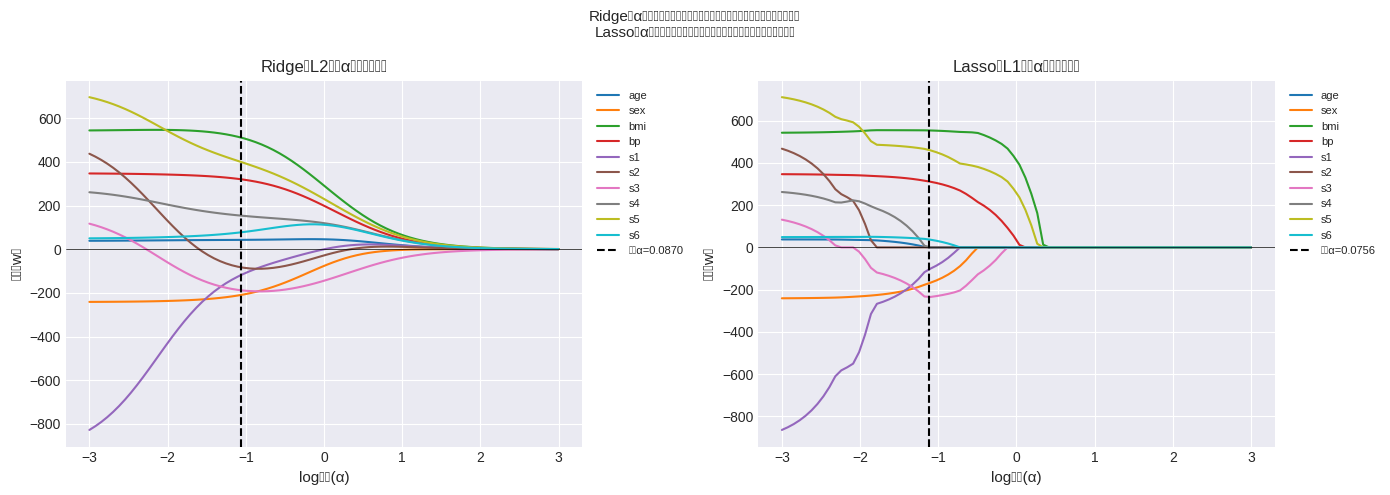

In [ ]:
# αを変化させた時の係数の変化（正則化パス）
alphas_path = np.logspace(-3, 3, 80)

coefs_ridge_path = np.array([
    Ridge(alpha=a).fit(X_train, y_train).coef_ for a in alphas_path
])
coefs_lasso_path = np.array([
    Lasso(alpha=a, max_iter=20000).fit(X_train, y_train).coef_
    for a in alphas_path
])

log_alphas = np.log10(alphas_path)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, name in enumerate(feature_names):
    axes[0].plot(log_alphas, coefs_ridge_path[:, i], label=name)
    axes[1].plot(log_alphas, coefs_lasso_path[:, i], label=name)

for ax, model_name, best_a in zip(
    axes,
    ['Ridge（L2）', 'Lasso（L1）'],
    [ridge_cv.alpha_, lasso_cv.alpha_]
):
    ax.axvline(np.log10(best_a), color='black', linestyle='--',
               linewidth=1.5, label=f'最適α={best_a:.4f}')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_xlabel('log₁₀(α)', fontsize=11)
    ax.set_ylabel('係数（w）', fontsize=11)
    ax.set_title(f'{model_name}：αと係数の関係', fontsize=12)
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.suptitle(
    'Ridge：αが大きくなるにつれ係数がゼロに近づく（ゼロにはならない）\n'
    'Lasso：αが大きくなるにつれ係数が順次ゼロになる（特徴量選択）',
    fontsize=11
)
plt.tight_layout()
plt.show()

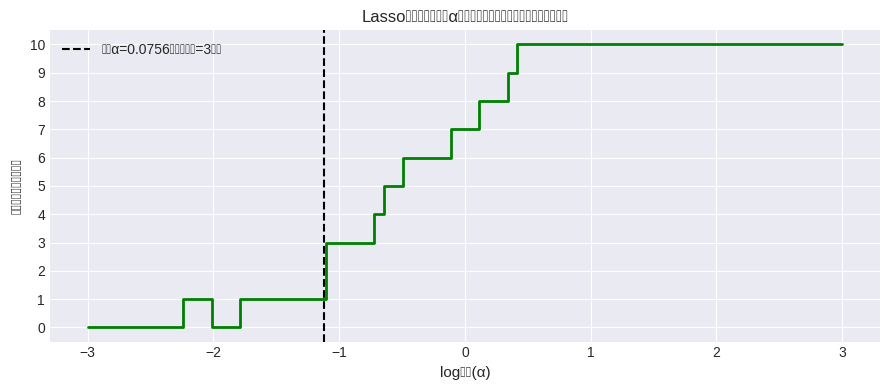

α を大きくする → より少ない特徴量でモデルを構成
α を小さくする → より多くの特徴量を使用
最適αはCV で自動選択（テストデータに触れずに決定）


In [ ]:
# Lassoのスパース性（αに対してゼロになる係数の数）
n_zeros = [np.sum(c == 0) for c in coefs_lasso_path]

fig, ax = plt.subplots(figsize=(9, 4))
ax.step(log_alphas, n_zeros, where='post', color='green', linewidth=2)
ax.axvline(np.log10(lasso_cv.alpha_), color='black', linestyle='--',
           label=f'最適α={lasso_cv.alpha_:.4f}（ゼロ係数={np.sum(lasso_cv.coef_==0)}個）')
ax.set_xlabel('log₁₀(α)', fontsize=11)
ax.set_ylabel('ゼロになった係数の数', fontsize=11)
ax.set_title('Lassoのスパース性：αを大きくすると次々と係数がゼロになる', fontsize=12)
ax.set_yticks(range(len(feature_names) + 1))
ax.legend()
plt.tight_layout()
plt.show()

print("α を大きくする → より少ない特徴量でモデルを構成")
print("α を小さくする → より多くの特徴量を使用")
print("最適αはCV で自動選択（テストデータに触れずに決定）")

---
## 9. 3手法の総合比較


In [ ]:
# 各手法の評価指標まとめ
results = pd.DataFrame({
    '手法': ['重回帰', 'Ridge', 'Lasso'],
    '最適α': ['-', f'{ridge_cv.alpha_:.4f}', f'{lasso_cv.alpha_:.4f}'],
    'テストR²':   [r2_lr,    r2_ridge,    r2_lasso],
    'テストRMSE': [rmse_lr,  rmse_ridge,  rmse_lasso],
    '訓練R²': [
        r2_score(y_train, lr.predict(X_train)),
        r2_score(y_train, ridge_cv.predict(X_train)),
        r2_score(y_train, lasso_cv.predict(X_train))
    ],
    'ゼロ係数数': [
        np.sum(np.abs(lr.coef_)       < 1e-6),
        np.sum(np.abs(ridge_cv.coef_) < 1e-6),
        np.sum(lasso_cv.coef_ == 0)
    ]
})
print("=== 3手法の比較 ===")
print(results.round(4).to_string(index=False))

=== 3手法の比較 ===
   手法    最適α  テストR²  テストRMSE   訓練R²  ゼロ係数数
  重回帰      - 0.4526  53.8534 0.5279      0
Ridge 0.0870 0.4605  53.4632 0.5213      0
Lasso 0.0756 0.4714  52.9213 0.5192      3


=== 5分割CVスコア（R²）の平均 ± 標準偏差 ===
  重回帰   : 0.4823 ± 0.0493
  Ridge : 0.4802 ± 0.0474
  Lasso : 0.4813 ± 0.0478


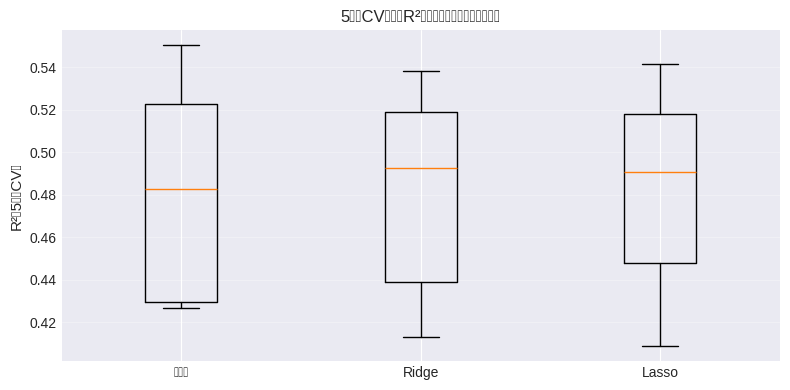

In [ ]:
# 交差検証スコアの分布（安定性の確認）
from sklearn.linear_model import Ridge as Ridge_, Lasso as Lasso_

cv_scores = {
    '重回帰':  cross_val_score(LinearRegression(),
                               X, y, cv=5, scoring='r2'),
    'Ridge':   cross_val_score(Ridge_(alpha=ridge_cv.alpha_),
                               X, y, cv=5, scoring='r2'),
    'Lasso':   cross_val_score(Lasso_(alpha=lasso_cv.alpha_, max_iter=20000),
                               X, y, cv=5, scoring='r2'),
}

print("=== 5分割CVスコア（R²）の平均 ± 標準偏差 ===")
for name, scores in cv_scores.items():
    print(f"  {name:6s}: {scores.mean():.4f} ± {scores.std():.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(list(cv_scores.values()), labels=list(cv_scores.keys()))
ax.set_ylabel('R²（5分割CV）', fontsize=11)
ax.set_title('5分割CVによるR²の分布（箱が小さい＝安定）', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

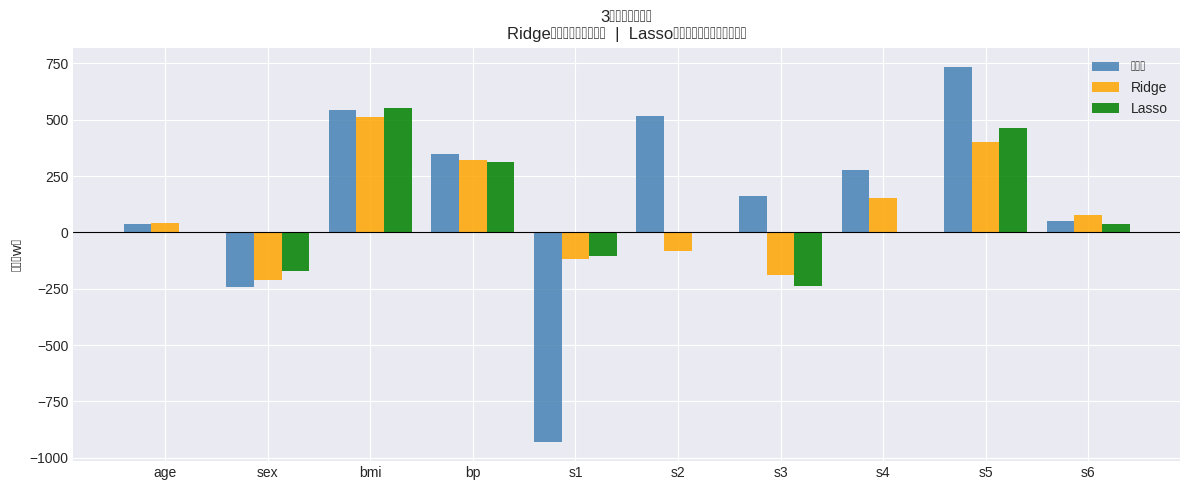

=== Lassoで選択された特徴量 ===
  選択（7個）: ['sex', 'bmi', 'bp', 's1', 's3', 's5', 's6']
  除外（3個）: ['age', 's2', 's4']


In [ ]:
# 係数の比較プロット（3手法を横並び）
x = np.arange(len(feature_names))
width = 0.27

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width, lr.coef_,       width, label='重回帰',  alpha=0.85, color='steelblue')
ax.bar(x,          ridge_cv.coef_, width, label='Ridge',   alpha=0.85, color='orange')
ax.bar(x + width,  lasso_cv.coef_, width, label='Lasso',   alpha=0.85, color='green')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(feature_names)
ax.set_ylabel('係数（w）', fontsize=11)
ax.set_title('3手法の係数比較\n'
             'Ridge：係数が縮小される  |  Lasso：一部の係数が完全にゼロ', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

print("=== Lassoで選択された特徴量 ===")
selected = [n for n, c in zip(feature_names, lasso_cv.coef_) if c != 0]
excluded = [n for n, c in zip(feature_names, lasso_cv.coef_) if c == 0]
print(f"  選択（{len(selected)}個）: {selected}")
print(f"  除外（{len(excluded)}個）: {excluded}")

---
## 10. まとめ：回帰分析の完全整理
。

In [ ]:
print("=" * 55)
print("  回帰分析のまとめ（本日で完全完結）")
print("=" * 55)

summary = """
【手法の整理】
  線形回帰  : y = wx + b  （単回帰）
  重回帰    : y = w₁x₁+…+wₚxₚ+b  （多変量）
  Ridge     : 重回帰 + α Σwⱼ²   （L2正則化）
  Lasso     : 重回帰 + α Σ|wⱼ|  （L1正則化）

【評価指標】
  RMSE : yと同じ単位の誤差，小さいほど良い
  R²   : 0〜1，1が最良（データの何%を説明）

【RidgeとLassoの使い分け】
  Ridge : 多重共線性あり，全特徴量を保持したい
  Lasso : 不要な特徴量が多い，解釈性を重視

【αの選択】
  RidgeCV / LassoCV で交差検証により自動決定
  → テストデータに触れずにαを決定できる

【特徴量の重要度（回帰）】
  標準化済みデータでは |wⱼ| が大きいほど重要
  次回の決定木 feature_importances_ と比較する
"""

print(summary)
print("【次回】分類問題")
print("  ロジスティック回帰（Sigmoid，交差エントロピー）")
print("  決定木（ジニ係数，可視化）")
print("  Random Forest（アンサンブル，feature_importances_）")

  回帰分析のまとめ（本日で完全完結）

【手法の整理】
  線形回帰  : y = wx + b  （単回帰）
  重回帰    : y = w₁x₁+…+wₚxₚ+b  （多変量）
  Ridge     : 重回帰 + α Σwⱼ²   （L2正則化）
  Lasso     : 重回帰 + α Σ|wⱼ|  （L1正則化）

【評価指標】
  RMSE : yと同じ単位の誤差，小さいほど良い
  R²   : 0〜1，1が最良（データの何%を説明）

【RidgeとLassoの使い分け】
  Ridge : 多重共線性あり，全特徴量を保持したい
  Lasso : 不要な特徴量が多い，解釈性を重視

【αの選択】
  RidgeCV / LassoCV で交差検証により自動決定
  → テストデータに触れずにαを決定できる

【特徴量の重要度（回帰）】
  標準化済みデータでは |wⱼ| が大きいほど重要
  次回の決定木 feature_importances_ と比較する

【次回】分類問題
  ロジスティック回帰（Sigmoid，交差エントロピー）
  決定木（ジニ係数，可視化）
  Random Forest（アンサンブル，feature_importances_）


---
## 11. 準備学習課題

**課題1**（100字程度・必須）  
RidgeとLassoの違いを，ペナルティの形・係数の挙動・特徴量選択の観点から説明せよ。

**課題2**（100字程度・必須）  
過学習とは何か，訓練R²とテストR²の関係を用いて説明せよ。

**課題3（次回への問い）**  
線形回帰の出力（連続値）を使って「合格/不合格」を判定しようとすると，
どのような問題が起きるか考えてみよ。
（ヒント：y が [0, 1] の範囲を超えたらどうなるか？）

**課題4（発展・任意）**  
ElasticNetはRidgeとLassoを組み合わせた手法である。
糖尿病データで実装し，R²を3手法と比較せよ。

---

### 解答欄

**課題1**:


**課題2**:


**課題3（次回への問い）**:


**課題4（任意）**:


In [ ]:
# 課題4 作業スペース（任意）：ElasticNet
from sklearn.linear_model import ElasticNetCV

# ここにコードを書く
# ヒント：l1_ratio パラメータで L1:L2 の比率を調整
# enet = ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, 1],
#                     alphas=alphas, cv=5)


---
## 参考文献

1. Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer.
2. Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly.
3. scikit-learn: Linear Models — https://scikit-learn.org/stable/modules/linear_model.html

---
*人工知能I 第3回実習ノートブック（改定案B）| 担当：浅川伸一*